# Session 18 — Video Analytics II: Multi-Object Tracking
**Phase 4 | Computer Vision & AI Course**

---

## What We'll Cover Today

| Topic | Description |
|---|---|
| MOT Problem | What tracking is, why it's hard |
| SORT | Kalman Filter + Hungarian Algorithm baseline |
| DeepSORT | Adding deep appearance features to SORT |
| ByteTrack | Associating **every** detection box (ECCV 2022) |
| Practical Lab | Tracking with `supervision` + Ultralytics YOLO |
| MOT Metrics | MOTA, IDF1, HOTA — understanding the benchmarks |
| Comparison | DeepSORT vs ByteTrack — when to use which |

**Estimated time:** ~60 minutes hands-on

> 💡 **Goal:** Understand the core ideas behind DeepSORT and ByteTrack, implement both using the `supervision` library, and evaluate their tracking performance.

---

## 1. Installation & Imports

In [ ]:
# Install required packages (run once)
# NOTE: Install PyTorch with CUDA support
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128 -q

# Core tracking & detection
!pip install ultralytics supervision -q

# Deep SORT (standalone implementation)
!pip install deep-sort-realtime -q

# Utilities
!pip install opencv-python matplotlib numpy scipy scikit-learn requests pillow -q

print('All packages installed!')

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.patches import FancyArrowPatch
from PIL import Image
import requests
from io import BytesIO
import time
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import linear_sum_assignment   # Hungarian Algorithm
from scipy.spatial.distance import cdist           # Cosine distance

import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

# Utility: load image from URL
def load_url_image(url, size=None):
    resp = requests.get(url, timeout=15, headers={'User-Agent': 'Mozilla/5.0'})
    img  = Image.open(BytesIO(resp.content)).convert('RGB')
    if size:
        img = img.resize(size, Image.LANCZOS)
    return np.array(img)

print('Imports ready!')

PyTorch: 2.9.1+cu128
CUDA available: True
Imports ready!


---
## 2. The Multi-Object Tracking Problem

**Multi-Object Tracking (MOT)** is the task of:
1. **Detecting** all objects of interest in each video frame
2. **Associating** each detection to the same object across frames
3. **Maintaining** a unique ID for every object throughout the video

The output is a set of **trajectories** — one continuous path per object.

### Why is MOT Hard?

| Challenge | Description |
|---|---|
| **Occlusion** | Objects temporarily hidden by other objects or scene elements |
| **ID Switches** | Tracker reassigns the wrong ID after occlusion or overlap |
| **Similar Appearance** | Multiple objects that look alike (e.g. players in same jersey) |
| **Fast Motion** | Large frame-to-frame displacements confuse motion models |
| **New / Leaving Objects** | Objects entering or exiting the scene need to be created/removed |

### Real-World Applications

Traffic surveillance, sports analytics, autonomous driving, retail footfall analysis, robotics, crowd monitoring.

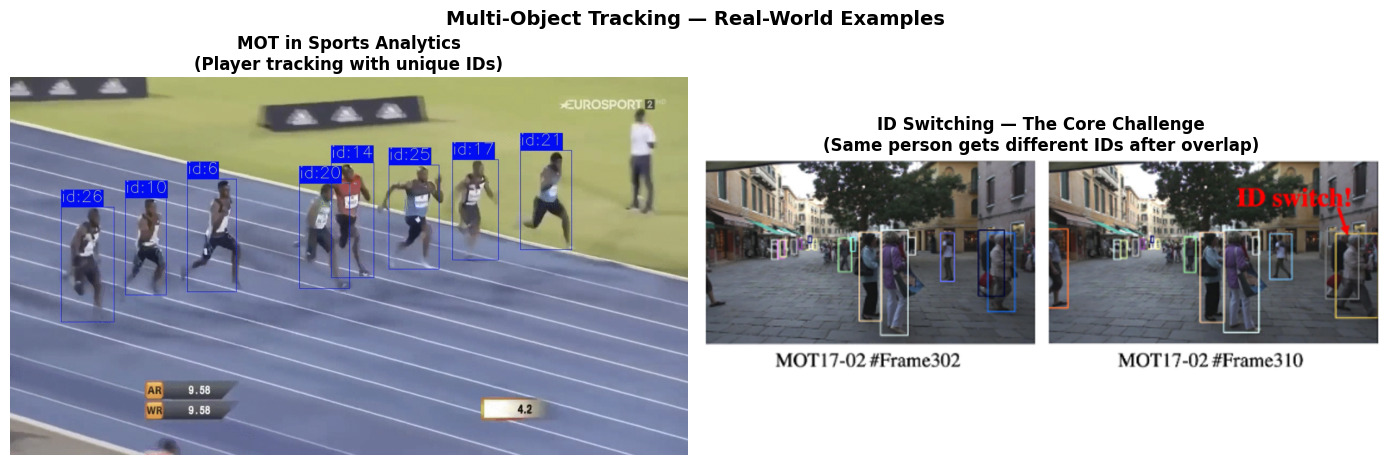

Source: datature.io — Introduction to BYTETrack
https://datature.io/blog/introduction-to-bytetrack-multi-object-tracking-by-associating-every-detection-box


In [2]:
# --- Show a real MOT example from the wild ---

# Pedestrian tracking example (from datature.io)
TRACKING_GIF_FRAME = "https://cdn.prod.website-files.com/67d7ebcca3cabb623904dcde/680a8745551d14ee8c9661d1_Screenshot%202025-04-24%20at%2011.47.19%E2%80%AFAM.png"

# ID-switching problem illustration (from datature.io)
ID_SWITCH_IMG = "https://cdn.prod.website-files.com/67d7ebcca3cabb623904dcde/67d7f31782fc546599bcf274_64588b140be9f8de8efc710f_e484d3e4.png"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

try:
    img1 = load_url_image(TRACKING_GIF_FRAME)
    axes[0].imshow(img1)
    axes[0].set_title('MOT in Sports Analytics\n(Player tracking with unique IDs)', fontsize=12, fontweight='bold')
    axes[0].axis('off')
except Exception as e:
    axes[0].text(0.5, 0.5, f'Image unavailable\n{e}', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].axis('off')

try:
    img2 = load_url_image(ID_SWITCH_IMG)
    axes[1].imshow(img2)
    axes[1].set_title('ID Switching — The Core Challenge\n(Same person gets different IDs after overlap)', fontsize=12, fontweight='bold')
    axes[1].axis('off')
except Exception as e:
    axes[1].text(0.5, 0.5, f'Image unavailable\n{e}', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].axis('off')

plt.suptitle('Multi-Object Tracking — Real-World Examples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Source: datature.io — Introduction to BYTETrack')
print('https://datature.io/blog/introduction-to-bytetrack-multi-object-tracking-by-associating-every-detection-box')

---
## 3. The Tracking-by-Detection Paradigm

Almost all modern trackers follow the **Tracking-by-Detection** pipeline:

```
Video Frame  →  Object Detector  →  Bounding Boxes
                                          ↓
              Kalman Filter (predict next position)
                                          ↓
              Data Association (match detections ↔ tracks)
                                          ↓
              Track Management (create / update / delete)
```

The **SORT (Simple Online and Realtime Tracking) algorithm (2016)** by Bewley et al. established this foundation. It uses just two components:
- **Kalman Filter** — predicts where each tracked object will be in the next frame
- **Hungarian Algorithm** — optimally matches detections to existing tracks

### 3.1 Kalman Filter — Motion Prediction

The Kalman filter models each track as a state vector:

$$\mathbf{x} = [u, v, s, r, \dot{u}, \dot{v}, \dot{s}]$$

where $(u, v)$ = centre position, $s$ = scale (area), $r$ = aspect ratio, and $\dot{x}$ = velocity terms.

It runs two steps every frame:
1. **Predict** — extrapolate forward using the motion model (constant velocity)
2. **Update** — correct the prediction using the new detection measurement

### 3.2 Hungarian Algorithm — Data Association

Given $M$ predicted boxes and $N$ detected boxes, build a cost matrix (IoU distance) and find the assignment that **minimises total cost** — solved in $O(n^3)$ time.

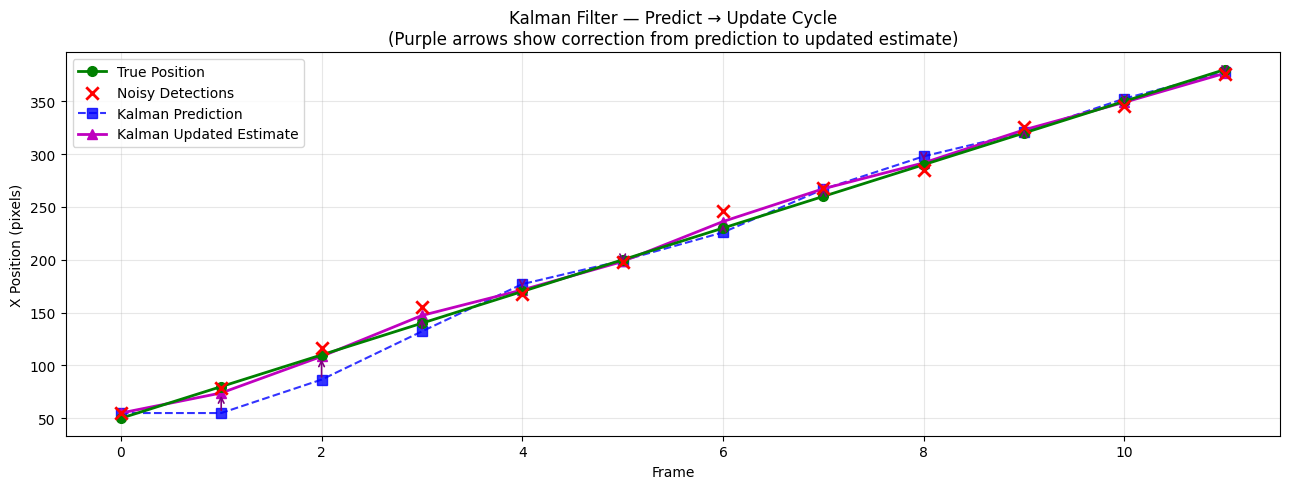

The Kalman filter predicts (blue dashed) then corrects toward the detection (purple arrow) to get the final estimate (magenta).


In [3]:
# ========================================================
# Visualise Kalman Predict → Update cycle
# ========================================================

np.random.seed(42)

# Simulate true trajectory (constant velocity + noise)
n_frames = 12
true_x = np.arange(n_frames) * 30 + 50
true_y = np.sin(np.arange(n_frames) * 0.5) * 30 + 200

# Simulated detections (true + noise)
det_x = true_x + np.random.randn(n_frames) * 10
det_y = true_y + np.random.randn(n_frames) * 10

# Simple 1D Kalman for illustration
# State: [x, vx], Process noise Q, Measurement noise R
class SimpleKalman1D:
    def __init__(self, x0):
        self.x  = np.array([x0, 0.0])   # [position, velocity]
        self.P  = np.eye(2) * 100        # Covariance
        self.F  = np.array([[1, 1],[0, 1]])  # State transition
        self.H  = np.array([[1, 0]])         # Measurement matrix
        self.Q  = np.eye(2) * 1              # Process noise
        self.R  = np.array([[25.0]])          # Measurement noise

    def predict(self):
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q
        return self.x[0]

    def update(self, z):
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)   # Kalman gain
        self.x = self.x + K.flatten() * (z - self.H @ self.x)
        self.P = (np.eye(2) - K @ self.H) @ self.P
        return self.x[0]

kf = SimpleKalman1D(det_x[0])
preds, updates = [], []
for i in range(n_frames):
    preds.append(kf.predict())
    updates.append(kf.update(det_x[i]))

fig, ax = plt.subplots(figsize=(13, 5))
frames = np.arange(n_frames)
ax.plot(frames, true_x,  'g-o', lw=2, ms=7, label='True Position', zorder=3)
ax.scatter(frames, det_x,    c='red',    s=80, zorder=4, label='Noisy Detections', marker='x', linewidths=2)
ax.plot(frames, preds,   'b--s', lw=1.5, ms=7, label='Kalman Prediction', alpha=0.8)
ax.plot(frames, updates, 'm-^', lw=2, ms=7, label='Kalman Updated Estimate')

for i in range(n_frames):
    ax.annotate('', xy=(i, updates[i]), xytext=(i, preds[i]),
                arrowprops=dict(arrowstyle='->', color='purple', lw=1.2))

ax.set(xlabel='Frame', ylabel='X Position (pixels)',
       title='Kalman Filter — Predict → Update Cycle\n(Purple arrows show correction from prediction to updated estimate)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('The Kalman filter predicts (blue dashed) then corrects toward the detection (purple arrow) to get the final estimate (magenta).')

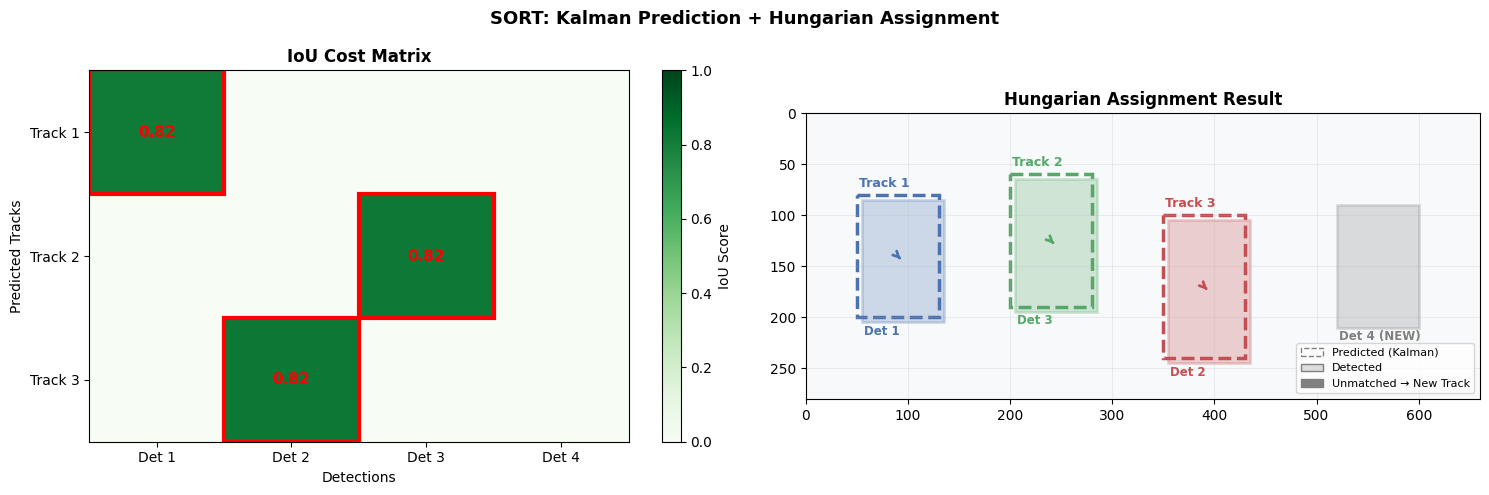

Red boxes in cost matrix = Hungarian optimal assignments
  Track 1  →  Detection 1  (IoU = 0.816)
  Track 2  →  Detection 3  (IoU = 0.821)
  Track 3  →  Detection 2  (IoU = 0.825)
  Detection 4 is unmatched → spawns a NEW track


In [4]:
# ========================================================
# Hungarian Algorithm — Optimal Assignment Demo
# ========================================================

def iou(boxA, boxB):
    """Compute IoU between two [x1,y1,x2,y2] boxes."""
    xA = max(boxA[0], boxB[0]); yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2]); yB = min(boxA[3], boxB[3])
    inter = max(0, xB-xA) * max(0, yB-yA)
    areaA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    return inter / float(areaA + areaB - inter + 1e-6)

# Predicted tracks (from Kalman filter)
tracks = [
    [50, 80, 130, 200],    # Track 1
    [200, 60, 280, 190],   # Track 2
    [350, 100, 430, 240],  # Track 3
]

# New detections this frame
detections = [
    [55, 85, 135, 205],    # Close to Track 1
    [355, 105, 435, 245],  # Close to Track 3
    [205, 65, 285, 195],   # Close to Track 2
    [520, 90, 600, 210],   # New object (no matching track)
]

# Build IoU cost matrix (we maximise IoU, so minimise 1-IoU)
cost_matrix = np.zeros((len(tracks), len(detections)))
for i, trk in enumerate(tracks):
    for j, det in enumerate(detections):
        cost_matrix[i, j] = 1 - iou(trk, det)

# Hungarian solution
row_ind, col_ind = linear_sum_assignment(cost_matrix)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Left: Cost Matrix Heatmap ---
ax = axes[0]
im = ax.imshow(1 - cost_matrix, cmap='Greens', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='IoU Score')
ax.set_xticks(range(len(detections))); ax.set_xticklabels([f'Det {j+1}' for j in range(len(detections))])
ax.set_yticks(range(len(tracks)));    ax.set_yticklabels([f'Track {i+1}' for i in range(len(tracks))])
ax.set_title('IoU Cost Matrix', fontsize=12, fontweight='bold')

for i, j in zip(row_ind, col_ind):
    ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, edgecolor='red', lw=3))
    ax.text(j, i, f'{1-cost_matrix[i,j]:.2f}', ha='center', va='center', color='red', fontweight='bold', fontsize=11)

ax.set_xlabel('Detections'); ax.set_ylabel('Predicted Tracks')

# --- Right: Visual bounding boxes with assignment ---
ax2 = axes[1]
ax2.set_xlim(0, 660); ax2.set_ylim(0, 280); ax2.invert_yaxis()
ax2.set_aspect('equal')
ax2.set_title('Hungarian Assignment Result', fontsize=12, fontweight='bold')
ax2.set_facecolor('#f8f9fa')

colors_trk = ['#4C72B0', '#55A868', '#C44E52']
for i, trk in enumerate(tracks):
    r = plt.Rectangle((trk[0], trk[1]), trk[2]-trk[0], trk[3]-trk[1],
                       linewidth=2.5, edgecolor=colors_trk[i], facecolor='none', linestyle='--')
    ax2.add_patch(r)
    ax2.text(trk[0]+2, trk[1]-8, f'Track {i+1}', color=colors_trk[i], fontweight='bold', fontsize=9)

for j, det in enumerate(detections):
    matched = j in col_ind
    clr = colors_trk[np.where(col_ind==j)[0][0]] if matched else 'gray'
    r = plt.Rectangle((det[0], det[1]), det[2]-det[0], det[3]-det[1],
                       linewidth=2, edgecolor=clr, facecolor=clr, alpha=0.25)
    ax2.add_patch(r)
    label = f'Det {j+1}' + ('' if matched else ' (NEW)')
    ax2.text(det[0]+2, det[3]+12, label, color=clr, fontsize=8.5, fontweight='bold')

# Draw assignment arrows
for i, j in zip(row_ind, col_ind):
    trk_cx = (tracks[i][0]+tracks[i][2])/2
    trk_cy = (tracks[i][1]+tracks[i][3])/2
    det_cx = (detections[j][0]+detections[j][2])/2
    det_cy = (detections[j][1]+detections[j][3])/2
    ax2.annotate('', xy=(det_cx, det_cy), xytext=(trk_cx, trk_cy),
                 arrowprops=dict(arrowstyle='->', color=colors_trk[i], lw=2))

ax2.legend(handles=[
    mpatches.Patch(facecolor='none', edgecolor='gray', linestyle='--', label='Predicted (Kalman)'),
    mpatches.Patch(facecolor='#dddddd', edgecolor='gray', label='Detected'),
    mpatches.Patch(facecolor='gray', edgecolor='gray', label='Unmatched → New Track'),
], loc='lower right', fontsize=8)

ax2.grid(True, alpha=0.2)
plt.suptitle('SORT: Kalman Prediction + Hungarian Assignment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Red boxes in cost matrix = Hungarian optimal assignments')
for i, j in zip(row_ind, col_ind):
    print(f'  Track {i+1}  →  Detection {j+1}  (IoU = {1-cost_matrix[i,j]:.3f})')
print(f'  Detection 4 is unmatched → spawns a NEW track')

---
## 4. DeepSORT — Deep Learning Extension

**DeepSORT** (Wojke et al., 2017) extends SORT with one key insight:

> *IoU alone is not enough. Add **appearance features** so the tracker can re-identify objects after occlusion.*

### 4.1 What DeepSORT Adds Over SORT

| Component | SORT | DeepSORT |
|---|---|---|
| **Motion model** | Kalman Filter (IoU) | Kalman Filter (Mahalanobis distance) |
| **Appearance** | ❌ None | ✅ Deep CNN embedding (Re-ID) |
| **Association metric** | IoU only | Weighted: motion + appearance |
| **Matching strategy** | Single-stage | **Cascade matching** (prioritise recent tracks) |
| **ID switches** | High | Significantly reduced |

### 4.2 The Re-Identification (ReID) Network

A small CNN (trained on the **MARS** person re-ID dataset) converts each detected bounding box crop into a **128-dimensional appearance embedding**. These embeddings are stored in a gallery buffer per track. At each frame:

1. Extract appearance embedding for each new detection
2. Compute **cosine distance** between detections and all stored track embeddings
3. Combine with Mahalanobis distance (motion) via a weighted sum
4. Run **cascade matching** — match tracks in order of most-recently-seen first

### 4.3 DeepSORT Architecture

![DeepSORT Architecture](https://assets-global.website-files.com/5f6bc60e665f54545a1e52a5/6318b85490c08ea0b9f9d02b_Deep%20SORT%20Architecture.png)

*Source: [Synclovis Systems — Understanding DeepSORT](https://www.synclovis.com/articles/understanding-deepsort-a-deep-dive-into-real-time-multi-object-tracking/)*

**Components shown:**
- **Yellow/solid** = original SORT components (Kalman, Hungarian)
- **Red/dashed** = DeepSORT additions (ReID CNN, appearance gallery, cascade matching)

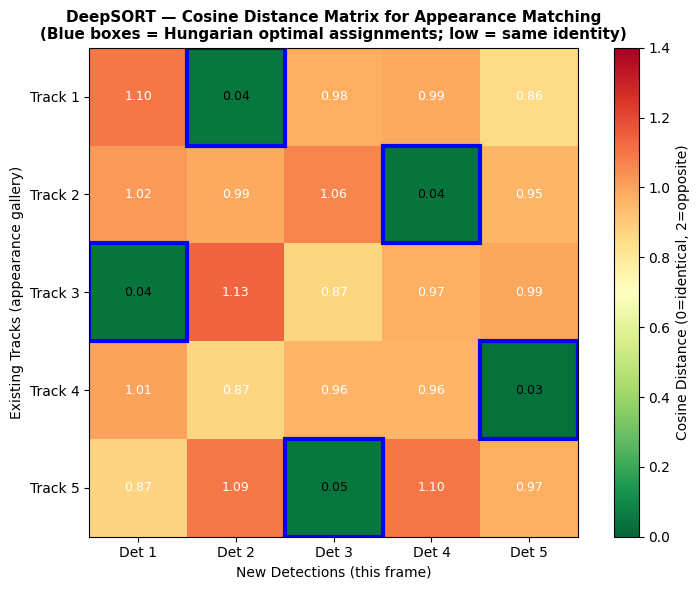

Hungarian optimal appearance matches:
  Track 1  →  Detection 2  (cosine dist = 0.044)
  Track 2  →  Detection 4  (cosine dist = 0.039)
  Track 3  →  Detection 1  (cosine dist = 0.040)
  Track 4  →  Detection 5  (cosine dist = 0.032)
  Track 5  →  Detection 3  (cosine dist = 0.048)

Note: The correct match (det = shuffled track) has low cosine distance.


In [5]:
# ========================================================
# Cosine Distance for Appearance Matching
# ========================================================
# DeepSORT compares appearance embeddings with cosine distance.
# Cosine distance = 1 - cosine_similarity.
# Low value → same person. High value → different person.

np.random.seed(0)

# Simulate 128-dim appearance embeddings for 5 tracks and 5 detections
n_tracks = 5
n_dets   = 5
emb_dim  = 128

# Create embeddings: same-index pairs are similar (same person), others differ
track_embs = np.random.randn(n_tracks, emb_dim)
det_embs   = track_embs.copy()
det_embs  += np.random.randn(n_tracks, emb_dim) * 0.3   # small noise for same identity

# Shuffle to make it non-trivial
shuffle_idx = [2, 0, 4, 1, 3]
det_embs = det_embs[shuffle_idx]

# Normalise to unit sphere (standard in ReID)
track_embs = track_embs / np.linalg.norm(track_embs, axis=1, keepdims=True)
det_embs   = det_embs   / np.linalg.norm(det_embs,   axis=1, keepdims=True)

# Cosine distance matrix
cos_dist = cdist(track_embs, det_embs, metric='cosine')

# Hungarian assignment on appearance
row_idx, col_idx = linear_sum_assignment(cos_dist)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cos_dist, cmap='RdYlGn_r', vmin=0, vmax=1.4)
plt.colorbar(im, ax=ax, label='Cosine Distance (0=identical, 2=opposite)')
ax.set_xticks(range(n_dets));   ax.set_xticklabels([f'Det {j+1}' for j in range(n_dets)])
ax.set_yticks(range(n_tracks)); ax.set_yticklabels([f'Track {i+1}' for i in range(n_tracks)])

for i in range(n_tracks):
    for j in range(n_dets):
        ax.text(j, i, f'{cos_dist[i,j]:.2f}', ha='center', va='center', fontsize=9,
                color='white' if cos_dist[i,j] > 0.8 else 'black')

for i, j in zip(row_idx, col_idx):
    ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, edgecolor='blue', lw=3))

ax.set_title('DeepSORT — Cosine Distance Matrix for Appearance Matching\n'
             '(Blue boxes = Hungarian optimal assignments; low = same identity)', fontsize=11, fontweight='bold')
ax.set_xlabel('New Detections (this frame)')
ax.set_ylabel('Existing Tracks (appearance gallery)')
plt.tight_layout()
plt.show()

print('Hungarian optimal appearance matches:')
for i, j in zip(row_idx, col_idx):
    print(f'  Track {i+1}  →  Detection {j+1}  (cosine dist = {cos_dist[i,j]:.3f})')
print(f'\nNote: The correct match (det = shuffled track) has low cosine distance.')

### 4.4 Cascade Matching — Prioritising Recent Tracks

DeepSORT uses a **cascade** instead of a flat assignment. Tracks are matched in order of how recently they were last seen:

```
For age = 1 to max_age:
    candidates = tracks last confirmed 'age' frames ago
    assignments = Hungarian(detections, candidates)
    remove matched detections from the pool

Unmatched detections → spawn new tracks
Unmatched tracks     → mark as 'tentative' or delete after max_age
```

**Why cascade?** When a track is occluded for several frames, the Kalman covariance grows (more uncertainty). Flat assignment could incorrectly match the uncertain occluded track to a wrong detection. Cascade prevents this by giving priority to fresh tracks.

---
## 5. ByteTrack — Associating Every Detection Box

> **Paper:** *ByteTrack: Multi-Object Tracking by Associating Every Detection Box*  
> Zhang et al., ECCV 2022 — [arxiv.org/abs/2110.06864](https://arxiv.org/abs/2110.06864)

### 5.1 The Core Insight

Most trackers throw away low-confidence detections (score < threshold). ByteTrack argues this wastes valuable information:

> *Occluded objects often have low detection scores — but they're still objects, not background.*

ByteTrack keeps **every** detection box and splits them into two pools for a **two-stage association**.

### 5.2 The BYTE Algorithm

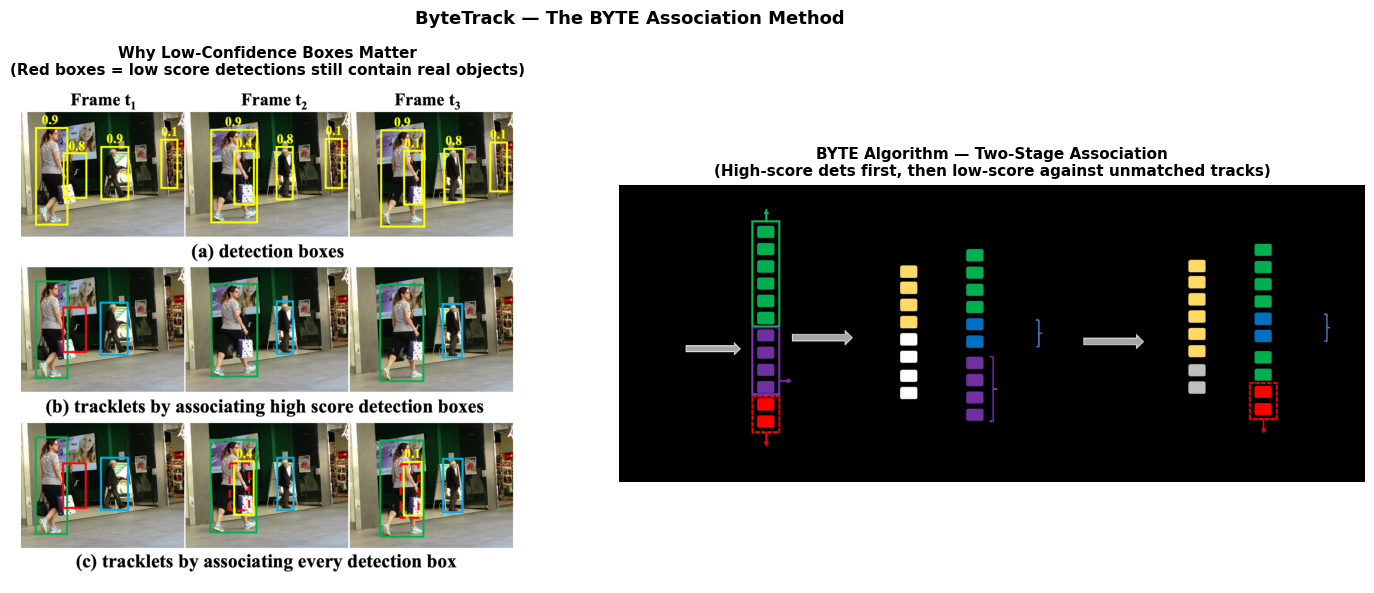

Source: Zhang et al. (2022) — ByteTrack: Multi-Object Tracking by Associating Every Detection Box
https://arxiv.org/abs/2110.06864


In [6]:
# --- Show the BYTE algorithm concept images ---

# BYTE low-confidence detection concept (from ByteTrack paper via datature.io)
BYTE_CONCEPT_URL = "https://cdn.prod.website-files.com/67d7ebcca3cabb623904dcde/67d7f31782fc546599bcf291_64588bc23b78b730227108d3_f9dc28fb.png"

# BYTE algorithm flowchart (from datature.io)
BYTE_ALGO_URL = "https://cdn.prod.website-files.com/67d7ebcca3cabb623904dcde/67d7f31782fc546599bcf27d_64588bc12835a851824c39d2_c0273485.png"

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

try:
    img1 = load_url_image(BYTE_CONCEPT_URL)
    axes[0].imshow(img1)
    axes[0].set_title('Why Low-Confidence Boxes Matter\n'
                      '(Red boxes = low score detections still contain real objects)', fontsize=11, fontweight='bold')
    axes[0].axis('off')
except Exception as e:
    axes[0].text(0.5, 0.5, f'Image unavailable\n{e}', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].axis('off')

try:
    img2 = load_url_image(BYTE_ALGO_URL)
    axes[1].imshow(img2)
    axes[1].set_title('BYTE Algorithm — Two-Stage Association\n'
                      '(High-score dets first, then low-score against unmatched tracks)', fontsize=11, fontweight='bold')
    axes[1].axis('off')
except Exception as e:
    axes[1].text(0.5, 0.5, f'Image unavailable\n{e}', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].axis('off')

plt.suptitle('ByteTrack — The BYTE Association Method', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Source: Zhang et al. (2022) — ByteTrack: Multi-Object Tracking by Associating Every Detection Box')
print('https://arxiv.org/abs/2110.06864')

### 5.3 BYTE Algorithm — Step by Step

```
Input: Detections D = {d₁, ..., dₙ} with scores s₁, ..., sₙ
       Active tracks T from previous frame
       Thresholds: τ_high (e.g. 0.6), τ_low (e.g. 0.1)

Step 1 — Split detections:
  D_high = {d | score(d) ≥ τ_high}      ← confident detections
  D_low  = {d | τ_low ≤ score(d) < τ_high}  ← uncertain (occluded?)

Step 2 — Predict with Kalman filter:
  T_pred = Kalman.predict(T)

Step 3 — First Association (high-confidence only):
  cost = IoU(T_pred, D_high)  or cosine(features)
  matches, unmatched_T, unmatched_D_high = Hungarian(cost)
  Update matched tracks with Kalman.update()

Step 4 — Second Association (unmatched tracks + low-confidence):
  cost = IoU(unmatched_T, D_low)     ← IoU only (ReID not reliable for occluded)
  matches2, lost_T, background_D = Hungarian(cost, threshold=lower)
  Update matched tracks
  Lost tracks → kept for max_lost_frames before deletion

Step 5 — New tracks:
  Unmatched D_high with score > τ_new → spawn new track
  Discard unmatched D_low (likely background)

Output: Updated trajectories with track IDs
```

**Key difference from DeepSORT:** ByteTrack uses **IoU** for both association stages — no expensive ReID model needed. This makes it significantly faster while maintaining strong accuracy.

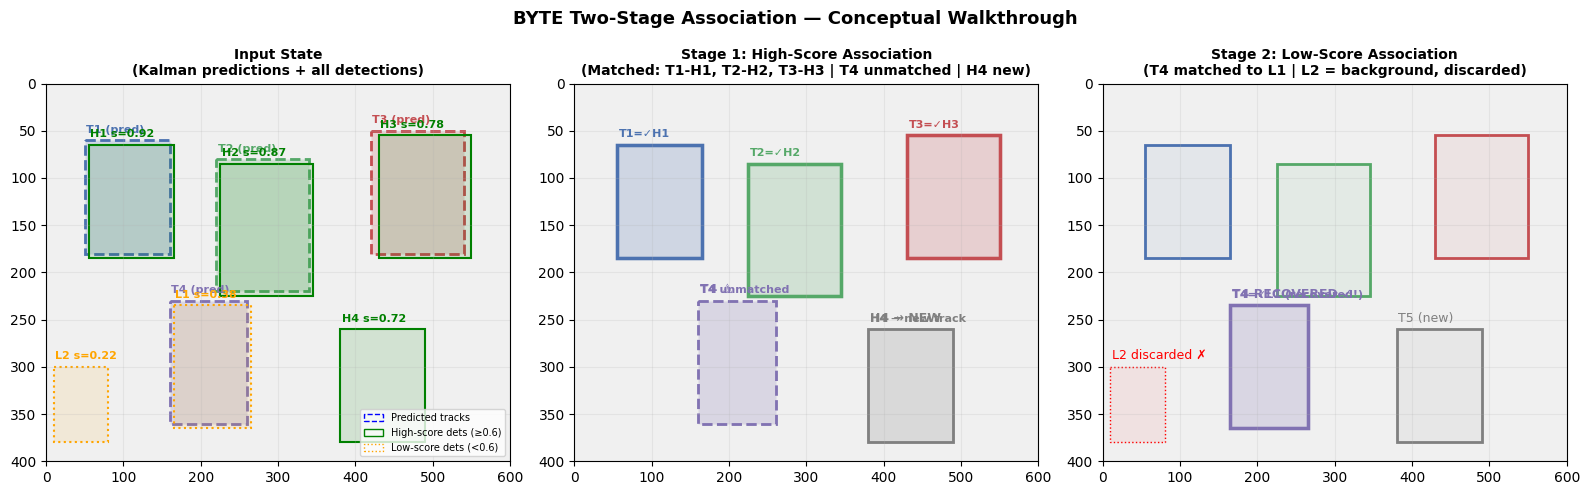

Key insight: The occluded Track 4 (low-score detection L1) would be LOST in standard trackers,
but ByteTrack RECOVERS it using Stage 2 association.


In [7]:
# ========================================================
# Visualise the Two-Stage BYTE Association
# ========================================================

np.random.seed(7)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('BYTE Two-Stage Association — Conceptual Walkthrough', fontsize=13, fontweight='bold')

# ---- Canvas setup ----
for ax in axes:
    ax.set_xlim(0, 600); ax.set_ylim(0, 400)
    ax.invert_yaxis()
    ax.set_facecolor('#f0f0f0')
    ax.grid(True, alpha=0.2)

# Predicted track positions (Kalman)
pred_tracks = {
    1: [50,  60, 160, 180],
    2: [220, 80, 340, 220],
    3: [420, 50, 540, 180],
    4: [160, 230, 260, 360],   # will become unmatched (occluded)
}

# Detections: high-score
det_high = {
    'H1': ([55, 65, 165, 185], 0.92),    # → Track 1
    'H2': ([225, 85, 345, 225], 0.87),   # → Track 2
    'H3': ([430, 55, 550, 185], 0.78),   # → Track 3
    'H4': ([380, 260, 490, 380], 0.72),  # → New Track
}

# Detections: low-score (occluded person)
det_low = {
    'L1': ([165, 235, 265, 365], 0.38),  # → Track 4 (occluded)
    'L2': ([10, 300, 80, 380], 0.22),    # background
}

trk_colors = {1: '#4C72B0', 2: '#55A868', 3: '#C44E52', 4: '#8172B2'}

def draw_box(ax, box, color, lw=2, ls='-', alpha=1.0, label=None):
    r = plt.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                       linewidth=lw, edgecolor=color, facecolor=color, alpha=alpha*0.2, linestyle=ls)
    ax.add_patch(r)
    r2 = plt.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                        linewidth=lw, edgecolor=color, facecolor='none', linestyle=ls)
    ax.add_patch(r2)
    if label:
        ax.text(box[0]+2, box[1]-8, label, color=color, fontsize=8, fontweight='bold')

# --- Panel 1: Input state ---
ax = axes[0]
ax.set_title('Input State\n(Kalman predictions + all detections)', fontsize=10, fontweight='bold')
for tid, box in pred_tracks.items():
    draw_box(ax, box, trk_colors[tid], lw=2, ls='--', label=f'T{tid} (pred)')
for dname, (box, score) in det_high.items():
    draw_box(ax, box, 'green', lw=1.5, alpha=0.6, label=f'{dname} s={score:.2f}')
for dname, (box, score) in det_low.items():
    draw_box(ax, box, 'orange', lw=1.5, ls=':', alpha=0.5, label=f'{dname} s={score:.2f}')
ax.legend(handles=[
    mpatches.Patch(edgecolor='blue', facecolor='none', linestyle='--', label='Predicted tracks'),
    mpatches.Patch(edgecolor='green', facecolor='none', label='High-score dets (≥0.6)'),
    mpatches.Patch(edgecolor='orange', facecolor='none', linestyle=':', label='Low-score dets (<0.6)'),
], loc='lower right', fontsize=7)

# --- Panel 2: Stage 1 — High-score association ---
ax = axes[1]
ax.set_title('Stage 1: High-Score Association\n(Matched: T1-H1, T2-H2, T3-H3 | T4 unmatched | H4 new)', fontsize=10, fontweight='bold')

matched1 = {1: 'H1', 2: 'H2', 3: 'H3'}
for tid, dname in matched1.items():
    box = det_high[dname][0]
    draw_box(ax, box, trk_colors[tid], lw=2.5, label=f'T{tid}=✓{dname}')
# Unmatched track 4
draw_box(ax, pred_tracks[4], trk_colors[4], lw=2, ls='--', label='T4 unmatched')
ax.text(pred_tracks[4][0]+2, pred_tracks[4][1]-8, 'T4 ⚠', color=trk_colors[4], fontsize=9, fontweight='bold')
# New detection H4
draw_box(ax, det_high['H4'][0], 'gray', lw=2, label='H4 → new track')
ax.text(det_high['H4'][0][0]+2, det_high['H4'][0][1]-8, 'H4 → NEW', color='gray', fontsize=9, fontweight='bold')

# --- Panel 3: Stage 2 — Low-score association ---
ax = axes[2]
ax.set_title('Stage 2: Low-Score Association\n(T4 matched to L1 | L2 = background, discarded)', fontsize=10, fontweight='bold')

for tid, dname in matched1.items():
    draw_box(ax, det_high[dname][0], trk_colors[tid], lw=2, alpha=0.4)
# T4 matched to L1
draw_box(ax, det_low['L1'][0], trk_colors[4], lw=2.5, label='T4=✓L1 (recovered!)')
ax.text(det_low['L1'][0][0]+2, det_low['L1'][0][1]-8, 'T4 RECOVERED ✓', color=trk_colors[4], fontsize=9, fontweight='bold')
# L2 discarded
draw_box(ax, det_low['L2'][0], 'red', lw=1, ls=':', alpha=0.3)
ax.text(det_low['L2'][0][0]+2, det_low['L2'][0][1]-8, 'L2 discarded ✗', color='red', fontsize=9)
# New track
draw_box(ax, det_high['H4'][0], 'gray', lw=2, alpha=0.4)
ax.text(det_high['H4'][0][0]+2, det_high['H4'][0][1]-8, 'T5 (new)', color='gray', fontsize=9)

plt.tight_layout()
plt.show()

print('Key insight: The occluded Track 4 (low-score detection L1) would be LOST in standard trackers,')
print('but ByteTrack RECOVERS it using Stage 2 association.')

---
## 6. Practical Lab — Tracking with `supervision` + Ultralytics

The [supervision](https://supervision.roboflow.com/) library provides clean, modern APIs for both ByteTrack and DeepSORT that plug directly into any YOLO model.

### Architecture:
```
Video Frame  →  YOLO Detector  →  sv.Detections  →  ByteTrack / DeepSORT  →  Annotated Frame
```

### 6.1 Setup — Download a Test Video

In [18]:
import supervision as sv
from ultralytics import YOLO
import urllib.request
import os

print(f'supervision version: {sv.__version__}')

# Download a short pedestrian test video from the MOT challenge sample
# Using a publicly available sample from Pexels (Creative Commons)
VIDEO_PATH = "./test_pedestrians.mp4"

if not os.path.exists(VIDEO_PATH):
    print('Downloading test video...')
    try:
        urllib.request.urlretrieve(VIDEO_URL, VIDEO_PATH)
        print(f'Downloaded → {VIDEO_PATH}')
    except Exception as e:
        print(f'Download failed: {e}')
        print('Please manually place a short pedestrian video at ./test_pedestrians.mp4')
else:
    print(f'Video already present: {VIDEO_PATH}')

# Verify
if os.path.exists(VIDEO_PATH):
    cap = cv2.VideoCapture(VIDEO_PATH)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    print(f'Video: {w}x{h} @ {fps:.1f} FPS | {frames} frames ({frames/fps:.1f}s)')

supervision version: 0.28.0
Video already present: ./test_pedestrians.mp4
Video: 1280x720 @ 24.0 FPS | 709 frames (29.6s)


Model: YOLOv8n loaded
Device: CUDA

Frame 1: 12 people detected


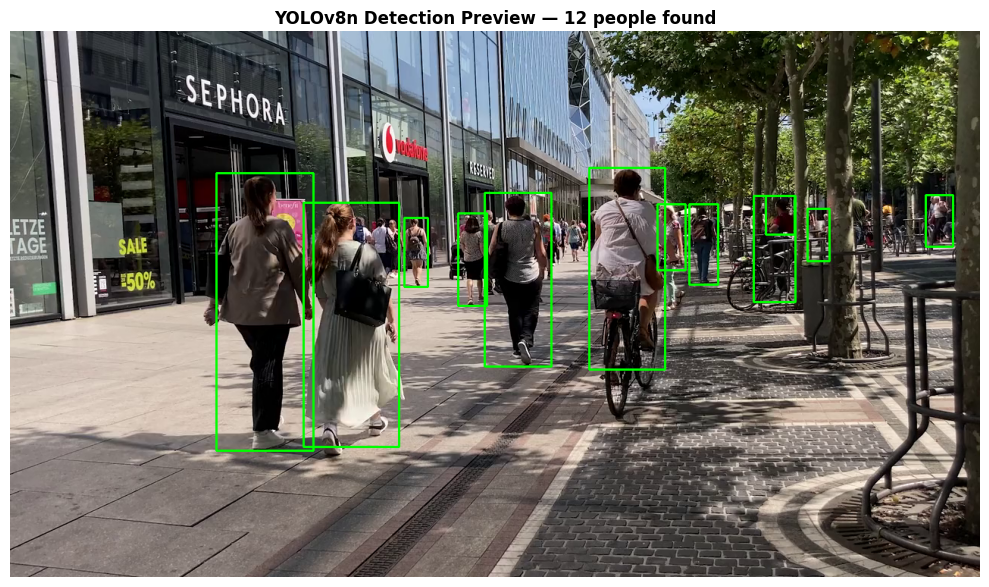

In [9]:
# ========================================================
# Load YOLOv8 Detector
# ========================================================

# Load YOLOv8n (nano — fastest) for tracking demo
# The model downloads automatically on first use
model = YOLO('yolov8n.pt')
print(f'Model: YOLOv8n loaded')
print(f'Device: {"CUDA" if torch.cuda.is_available() else "CPU"}')

# Preview: run detection on one frame to confirm setup
cap = cv2.VideoCapture(VIDEO_PATH)
ret, frame = cap.read()
cap.release()

if ret:
    results = model(frame, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)
    # Keep only people (class 0)
    detections = detections[detections.class_id == 0]
    print(f'\nFrame 1: {len(detections)} people detected')

    # Show detection preview
    annotated = frame.copy()
    for box in detections.xyxy:
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 255, 0), 2)

    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title(f'YOLOv8n Detection Preview — {len(detections)} people found', fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

### 6.2 ByteTrack Tracking

In [19]:
# ========================================================
# ByteTrack with supervision
# ========================================================

OUTPUT_BYTETRACK = './tracked_bytetrack.mp4'
MAX_FRAMES = 150   # process first 5 seconds at 30fps — increase for longer run

# Initialise ByteTrack tracker
byte_tracker = sv.ByteTrack(
    track_activation_threshold=0.25,   # min score to create a new track
    lost_track_buffer=30,              # frames to keep lost tracks alive
    minimum_matching_threshold=0.8,    # IoU threshold for association
    frame_rate=30
)

# Annotators
box_annotator  = sv.BoxAnnotator(thickness=2)
label_annotator = sv.LabelAnnotator(text_scale=0.5, text_thickness=1)
trace_annotator = sv.TraceAnnotator(trace_length=30, thickness=2)

# Colour palette for track IDs
palette = sv.ColorPalette.from_hex(['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7',
                                    '#DDA0DD','#98D8C8','#F7DC6F','#BB8FCE','#85C1E9'])

cap     = cv2.VideoCapture(VIDEO_PATH)
fps     = cap.get(cv2.CAP_PROP_FPS)
W       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
writer  = cv2.VideoWriter(OUTPUT_BYTETRACK, cv2.VideoWriter_fourcc(*'mp4v'), fps, (W, H))

frame_id        = 0
track_history   = {}   # track_id → list of centre points
id_switches_est = 0
times           = []

print('Running ByteTrack...')

while cap.isOpened() and frame_id < MAX_FRAMES:
    ret, frame = cap.read()
    if not ret:
        break

    t0 = time.time()

    # Detect
    results    = model(frame, verbose=False, classes=[0])[0]   # class 0 = person
    detections = sv.Detections.from_ultralytics(results)

    # Track
    detections = byte_tracker.update_with_detections(detections)

    times.append(time.time() - t0)

    # Annotate
    labels = [f'#{tid}' for tid in detections.tracker_id] if detections.tracker_id is not None else []

    annotated = frame.copy()
    annotated = trace_annotator.annotate(annotated, detections)
    annotated = box_annotator.annotate(annotated, detections)
    annotated = label_annotator.annotate(annotated, detections, labels=labels)

    # Info overlay
    n_tracks = len(set(detections.tracker_id)) if detections.tracker_id is not None else 0
    cv2.putText(annotated, f'ByteTrack | Frame {frame_id} | Tracks: {n_tracks} | {1/times[-1]:.1f} FPS',
                (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 200, 0), 2)

    writer.write(annotated)
    frame_id += 1

cap.release()
writer.release()

avg_fps = 1 / np.mean(times)
print(f'Done! {frame_id} frames processed.')
print(f'Average FPS: {avg_fps:.1f}')
print(f'Saved → {OUTPUT_BYTETRACK}')

Running ByteTrack...
Done! 150 frames processed.
Average FPS: 47.0
Saved → ./tracked_bytetrack.mp4


### 6.3 DeepSORT Tracking

In [20]:
# ========================================================
# DeepSORT with deep_sort_realtime
# ========================================================

from deep_sort_realtime.deepsort_tracker import DeepSort

OUTPUT_DEEPSORT = './tracked_deepsort.mp4'

# Initialise DeepSORT
deepsort_tracker = DeepSort(
    max_age=30,                  # frames before deleting a lost track
    n_init=3,                    # consecutive detections to confirm a track
    max_iou_distance=0.7,        # IoU distance threshold for matching
    max_cosine_distance=0.4,     # appearance embedding distance threshold
    nn_budget=None,              # max size of appearance gallery per track
    embedder='mobilenet',        # ReID backbone: 'mobilenet', 'torchreid', 'clip_RN50'
    half=True,                   # FP16 for faster inference on GPU
    bgr=True                     # OpenCV reads BGR
)

cap    = cv2.VideoCapture(VIDEO_PATH)
fps    = cap.get(cv2.CAP_PROP_FPS)
W      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
writer = cv2.VideoWriter(OUTPUT_DEEPSORT, cv2.VideoWriter_fourcc(*'mp4v'), fps, (W, H))

frame_id = 0
times_ds = []

# Track colour map
track_colours = {}

def get_colour(tid):
    if tid not in track_colours:
        np.random.seed(abs(hash(str(tid))) % (2**31))
        track_colours[tid] = tuple(int(c) for c in np.random.randint(100, 255, 3))
    return track_colours[tid]

print('Running DeepSORT...')

while cap.isOpened() and frame_id < MAX_FRAMES:
    ret, frame = cap.read()
    if not ret:
        break

    t0 = time.time()

    # Detect with YOLO — get [x1,y1,x2,y2,conf,cls]
    results = model(frame, verbose=False, classes=[0])[0]
    boxes   = results.boxes

    # DeepSORT expects: list of ([x1,y1,w,h], conf, class_name)
    raw_detections = []
    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf            = box.conf[0].item()
        w, h            = x2 - x1, y2 - y1
        raw_detections.append(([x1, y1, w, h], conf, 'person'))

    # Update tracker
    tracks = deepsort_tracker.update_tracks(raw_detections, frame=frame)

    times_ds.append(time.time() - t0)

    # Draw tracks
    annotated = frame.copy()
    active = 0
    for track in tracks:
        if not track.is_confirmed():
            continue
        active += 1
        tid  = track.track_id
        ltrb = track.to_ltrb()
        x1, y1, x2, y2 = map(int, ltrb)
        clr  = get_colour(tid)
        cv2.rectangle(annotated, (x1, y1), (x2, y2), clr, 2)
        cv2.rectangle(annotated, (x1, y1-22), (x1+60, y1), clr, -1)
        cv2.putText(annotated, f'#{tid}', (x1+4, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255,255,255), 1)

    cv2.putText(annotated, f'DeepSORT | Frame {frame_id} | Tracks: {active} | {1/times_ds[-1]:.1f} FPS',
                (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 200, 255), 2)

    writer.write(annotated)
    frame_id += 1

cap.release()
writer.release()

avg_fps_ds = 1 / np.mean(times_ds)
print(f'Done! {frame_id} frames processed.')
print(f'Average FPS: {avg_fps_ds:.1f}')
print(f'Saved → {OUTPUT_DEEPSORT}')

Running DeepSORT...
Done! 150 frames processed.
Average FPS: 10.0
Saved → ./tracked_deepsort.mp4


### 6.4 Side-by-Side Frame Comparison

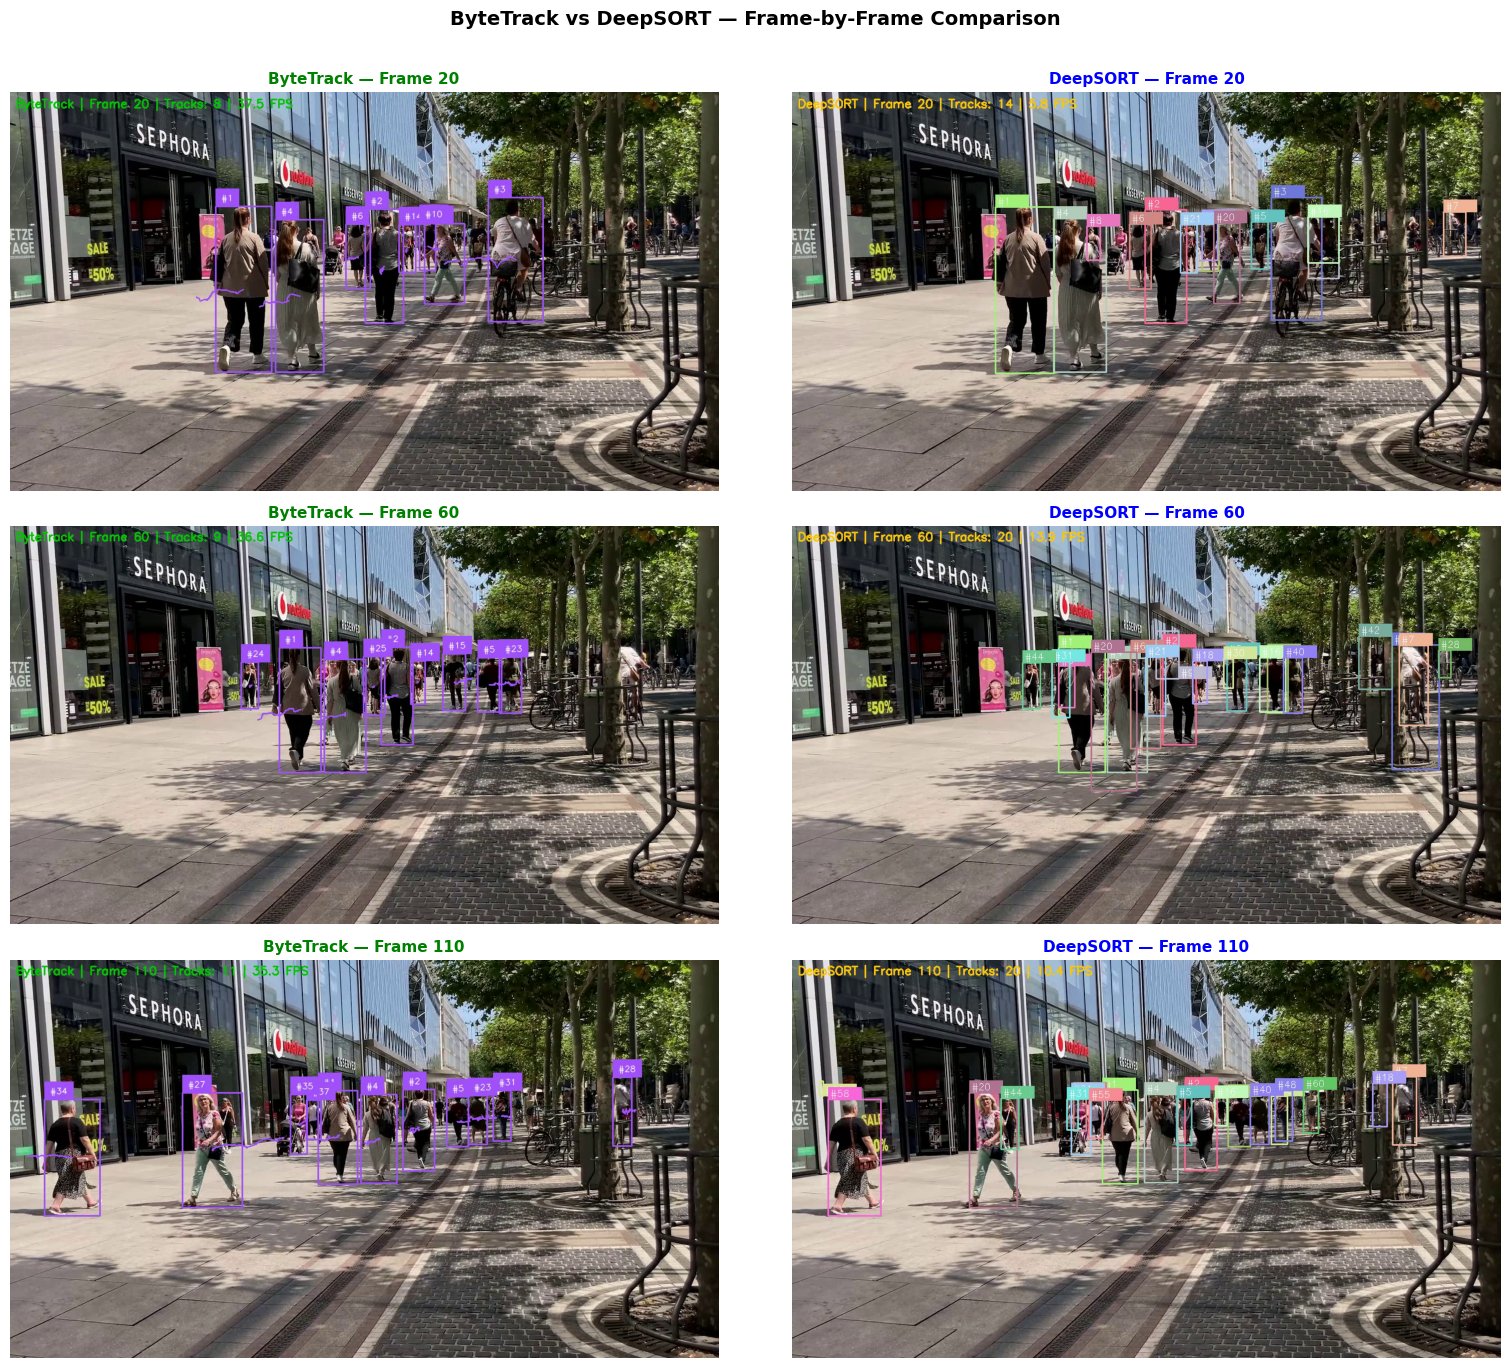

Observation points to look for:
  - Are the same people assigned the same ID in both trackers?
  - How do the trackers handle occlusion (one person passing in front of another)?
  - Which tracker maintains IDs more consistently?


In [13]:
# ========================================================
# Extract and display sample frames from both trackers
# ========================================================

def extract_frame(video_path, frame_number):
    """Extract a single frame from a video file."""
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    ret, frame = cap.read()
    cap.release()
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) if ret else None

sample_frames = [20, 60, 110]

fig, axes = plt.subplots(len(sample_frames), 2, figsize=(16, len(sample_frames)*4.5))
fig.suptitle('ByteTrack vs DeepSORT — Frame-by-Frame Comparison', fontsize=14, fontweight='bold', y=1.01)

for row, fid in enumerate(sample_frames):
    for col, (vid_path, title, clr) in enumerate([
        (OUTPUT_BYTETRACK, 'ByteTrack', 'green'),
        (OUTPUT_DEEPSORT,  'DeepSORT',  'blue'),
    ]):
        frame = extract_frame(vid_path, fid)
        if frame is not None:
            axes[row, col].imshow(frame)
            axes[row, col].set_title(f'{title} — Frame {fid}', fontsize=11, fontweight='bold', color=clr)
        else:
            axes[row, col].text(0.5, 0.5, 'Frame unavailable', ha='center', va='center',
                                transform=axes[row, col].transAxes, fontsize=12)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print('Observation points to look for:')
print('  - Are the same people assigned the same ID in both trackers?')
print('  - How do the trackers handle occlusion (one person passing in front of another)?')
print('  - Which tracker maintains IDs more consistently?')

---
## 7. MOT Evaluation Metrics

Three metrics are essential for evaluating multi-object trackers:

### 7.1 MOTA — Multiple Object Tracking Accuracy

$$\text{MOTA} = 1 - \frac{\sum_t (FN_t + FP_t + IDS_t)}{\sum_t GT_t}$$

- **FN** = False Negatives (missed objects)
- **FP** = False Positives (ghost detections)
- **IDS** = Identity Switches
- **GT** = Ground Truth count

> ⚠️ **Limitation:** MOTA is dominated by detection quality (FN, FP) and **underweights association quality**.

### 7.2 IDF1 — ID F1 Score

$$\text{ID F1} = \frac{2 \cdot IDTP}{2 \cdot IDTP + IDFP + IDFN}$$

- Measures **identity consistency** — how well the tracker maintains the same ID for the same person
> ⚠️ **Limitation:** IDF1 overemphasises association and ignores detection quality.

### 7.3 HOTA — Higher Order Tracking Accuracy (Modern Standard)

$$\text{HOTA} = \sqrt{\text{DetA} \times \text{AssA}}$$

- **DetA** = Detection accuracy (localisation quality)
- **AssA** = Association accuracy (trajectory consistency)
- Geometric mean → **balanced** between detection and association

> ✅ HOTA is now the **standard benchmark metric** for MOT (replaces MOTA as the primary metric).

### 7.4 Additional Metrics

| Metric | Meaning |
|---|---|
| **FPS** | Frames per second — real-time capability |
| **MT** | Mostly Tracked (≥80% of track length covered) |
| **ML** | Mostly Lost (≤20% of track length covered) |
| **IDS** | Identity Switches (lower = better) |
| **FRAG** | Track fragmentations |
| **MOTP** | Multiple Object Tracking Precision (localisation accuracy) |

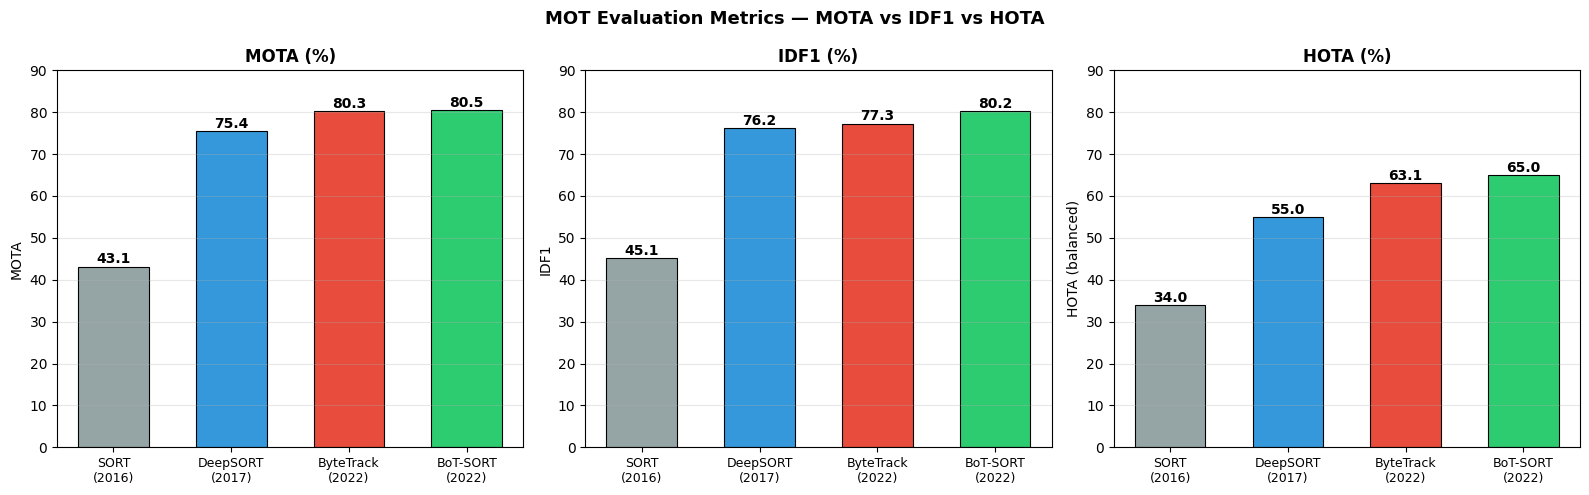

Benchmark: MOT17 test set (pedestrian tracking, multiple sequences)
Sources:
  - SORT: Bewley et al. (2016) arXiv:1602.00763
  - DeepSORT: Wojke et al. (2017) arXiv:1703.07402
  - ByteTrack: Zhang et al. (2022) arXiv:2110.06864
  - BoT-SORT: Aharon et al. (2022) arXiv:2206.14651


In [14]:
# ========================================================
# Visualise MOT Metrics — Conceptual Breakdown
# ========================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('MOT Evaluation Metrics — MOTA vs IDF1 vs HOTA', fontsize=13, fontweight='bold')

# --- Tracker benchmark results on MOT17 (published numbers) ---
trackers = ['SORT\n(2016)', 'DeepSORT\n(2017)', 'ByteTrack\n(2022)', 'BoT-SORT\n(2022)']
mota     = [43.1, 75.4, 80.3, 80.5]
idf1     = [45.1, 76.2, 77.3, 80.2]
hota     = [34.0, 55.0, 63.1, 65.0]   # approximate for SORT/DeepSORT

x = np.arange(len(trackers))
bar_colors = ['#95A5A6', '#3498DB', '#E74C3C', '#2ECC71']

for ax, (metric, values, ylabel) in zip(axes, [
    ('MOTA (%)', mota, 'MOTA'),
    ('IDF1 (%)', idf1, 'IDF1'),
    ('HOTA (%)', hota, 'HOTA (balanced)'),
]):
    bars = ax.bar(x, values, color=bar_colors, edgecolor='black', linewidth=0.8, width=0.6)
    ax.set_xticks(x); ax.set_xticklabels(trackers, fontsize=9)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 90); ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.8, f'{val:.1f}',
                ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print('Benchmark: MOT17 test set (pedestrian tracking, multiple sequences)')
print('Sources:')
print('  - SORT: Bewley et al. (2016) arXiv:1602.00763')
print('  - DeepSORT: Wojke et al. (2017) arXiv:1703.07402')
print('  - ByteTrack: Zhang et al. (2022) arXiv:2110.06864')
print('  - BoT-SORT: Aharon et al. (2022) arXiv:2206.14651')

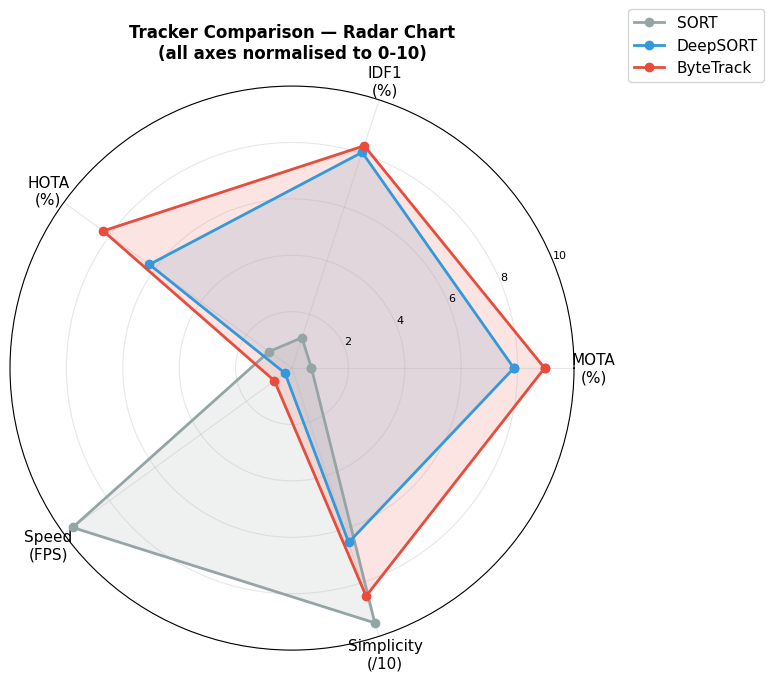

Speed note: SORT runs at ~260 FPS (pure CPU), DeepSORT ~18 FPS (GPU, ReID bottleneck),
ByteTrack ~30 FPS (GPU, no ReID inference needed).


In [16]:
# ========================================================
# Radar Chart — Multi-dimensional Tracker Comparison
# ========================================================

from matplotlib.patches import FancyArrowPatch

labels = ['MOTA\n(%)', 'IDF1\n(%)', 'HOTA\n(%)', 'Speed\n(FPS)', 'Simplicity\n(/10)']
N = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

# Normalise all to 0-10 scale (element-wise per metric)
def norm(vals, vmin, vmax):
    return [(v - mn) / (mx - mn) * 10 for v, mn, mx in zip(vals, vmin, vmax)]

data = {
    'SORT':      norm([43.1, 45.1, 34.0, 260,  9.5], [40, 40, 30, 10, 0], [85, 85, 70, 270, 10]),
    'DeepSORT':  norm([75.4, 76.2, 55.0,  18,  6.5], [40, 40, 30, 10, 0], [85, 85, 70, 270, 10]),
    'ByteTrack': norm([80.3, 77.3, 63.1,  30,  8.5], [40, 40, 30, 10, 0], [85, 85, 70, 270, 10]),
}

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})

colors_r = ['#95A5A6', '#3498DB', '#E74C3C']
for (name, values), color in zip(data.items(), colors_r):
    vals = values + values[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=name, color=color)
    ax.fill(angles, vals, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 10)
ax.set_yticks([2, 4, 6, 8, 10])
ax.set_yticklabels(['2', '4', '6', '8', '10'], fontsize=8)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)
ax.set_title('Tracker Comparison — Radar Chart\n(all axes normalised to 0-10)',
             fontsize=12, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Speed note: SORT runs at ~260 FPS (pure CPU), DeepSORT ~18 FPS (GPU, ReID bottleneck),')
print('ByteTrack ~30 FPS (GPU, no ReID inference needed).')

---
## 8. DeepSORT vs ByteTrack — When to Use Which

### Head-to-Head Summary

| Criterion | DeepSORT | ByteTrack |
|---|---|---|
| **Year** | 2017 | 2022 |
| **ReID network** | ✅ Required (CNN) | ❌ Not needed |
| **Association metric** | Motion + Appearance | IoU-only (two-stage) |
| **Low-confidence dets** | ❌ Discarded | ✅ Used in Stage 2 |
| **Speed** | Slower (ReID bottleneck) | Faster (no feature extraction) |
| **ID consistency** | Strong (appearance memory) | Strong (low-score recovery) |
| **MOT17 MOTA** | ~75.4 | ~80.3 |
| **MOT17 HOTA** | ~55.0 | ~63.1 |
| **Best for** | Long occlusions, re-entry | Crowded scenes, real-time |
| **Complexity** | Higher (ReID training) | Lower (plug-and-play) |

### Decision Guide

**Use ByteTrack when:**
- You need real-time speed
- The detector is strong (YOLOv8+)
- Scenes are crowded with many occlusions
- You don't have a domain-specific ReID model

**Use DeepSORT when:**
- Objects disappear for many frames and need to be re-identified on return
- You have a pre-trained ReID model for your domain (e.g. faces, vehicles)
- Appearance is more reliable than position (camera cuts, teleports)
- Speed is less critical than ID consistency

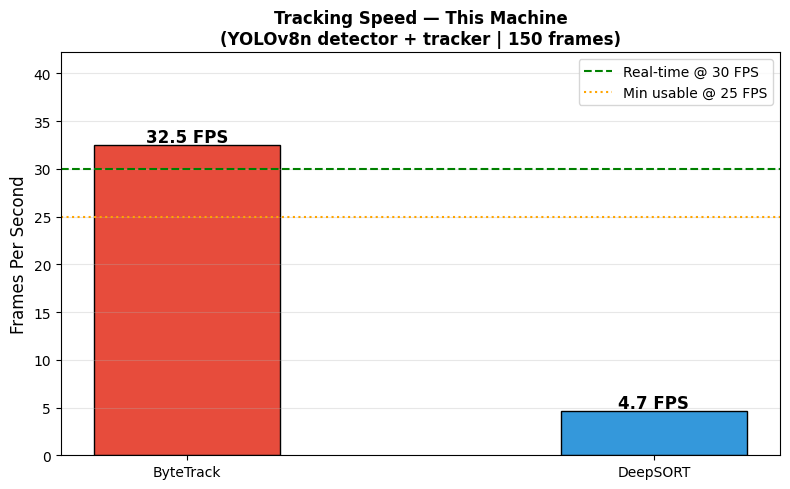

ByteTrack: 32.5 FPS
DeepSORT:  4.7 FPS
ByteTrack is 6.9x faster than DeepSORT on this machine
(ReID feature extraction is the main bottleneck in DeepSORT)


In [17]:
# ========================================================
# FPS Comparison on this machine
# ========================================================

if 'avg_fps' in dir() and 'avg_fps_ds' in dir():
    fig, ax = plt.subplots(figsize=(8, 5))

    trackers_lab = ['ByteTrack', 'DeepSORT']
    speeds = [avg_fps, avg_fps_ds]
    colors_bar = ['#E74C3C', '#3498DB']

    bars = ax.bar(trackers_lab, speeds, color=colors_bar, edgecolor='black', linewidth=1, width=0.4)
    ax.axhline(30, color='green', linestyle='--', linewidth=1.5, label='Real-time @ 30 FPS')
    ax.axhline(25, color='orange', linestyle=':', linewidth=1.5, label='Min usable @ 25 FPS')

    for bar, speed in zip(bars, speeds):
        ax.text(bar.get_x()+bar.get_width()/2, speed+0.3, f'{speed:.1f} FPS',
                ha='center', fontweight='bold', fontsize=12)

    ax.set_ylabel('Frames Per Second', fontsize=12)
    ax.set_title(f'Tracking Speed — This Machine\n(YOLOv8n detector + tracker | {MAX_FRAMES} frames)',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.set_ylim(0, max(speeds) * 1.3)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    speedup = avg_fps / avg_fps_ds
    print(f'ByteTrack: {avg_fps:.1f} FPS')
    print(f'DeepSORT:  {avg_fps_ds:.1f} FPS')
    print(f'ByteTrack is {speedup:.1f}x faster than DeepSORT on this machine')
    print(f'(ReID feature extraction is the main bottleneck in DeepSORT)')
else:
    print('Run both tracking cells first to see the speed comparison.')

---
## 9. ByteTrack in Action — Real Surveillance Tracking

The image below shows ByteTrack deployed on a real pedestrian surveillance scenario. Each colour represents a unique person ID maintained across the video sequence.

![ByteTrack Surveillance Demo](https://cdn.prod.website-files.com/67d7ebcca3cabb623904dcde/680a87a700c83d617bcf8b04_Screenshot%202025-04-24%20at%2011.48.50%E2%80%AFAM.png)

*Source: [datature.io — Introduction to BYTETrack](https://datature.io/blog/introduction-to-bytetrack-multi-object-tracking-by-associating-every-detection-box)*

And here is ByteTrack applied to sports — tracking basketball players across frames with distinct IDs for each player colour group:

![ByteTrack Basketball Demo](https://cdn.prod.website-files.com/67d7ebcca3cabb623904dcde/69ae7ca62d023b669cf1d796_yolov8.webp)

*Source: [datature.io — BYTETrack basketball demo](https://datature.io/blog/introduction-to-bytetrack-multi-object-tracking-by-associating-every-detection-box)*

---
## 10. Exercises

Try these extensions after the main lab:

**Exercise 1 — Tune ByteTrack thresholds**  
Adjust `track_activation_threshold` (0.1 → 0.5) and `lost_track_buffer` (10 → 60). How do these affect ID stability and ghost tracks?

**Exercise 2 — Track a different class**  
Change `classes=[0]` (person) to `classes=[2]` (car) or `classes=[0, 2]`. Does the tracker handle mixed classes well?

**Exercise 3 — Count people crossing a line**  
Use `sv.LineZone` from supervision to count how many unique track IDs cross a defined line in the frame.

```python
line = sv.LineZone(start=sv.Point(x=300, y=0), end=sv.Point(x=300, y=720))
line_annotator = sv.LineZoneAnnotator()
# In the loop:
line.trigger(detections)
frame = line_annotator.annotate(frame, line_count_zone=line)
```

**Exercise 4 — Heatmap of movement**  
Accumulate track centre points across all frames and plot a 2D histogram heatmap showing where people spend most time.

**Exercise 5 — StrongSORT**  
Try `sv.StrongSORT()` — a DeepSORT variant with ECC alignment and OSNet ReID. Compare it to both ByteTrack and DeepSORT on your video.

In [ ]:
# ========================================================
# Exercise Starter: People Heatmap
# ========================================================

heatmap = np.zeros((H, W), dtype=np.float32)

# Re-run ByteTrack on the video and accumulate centre points
byte_tracker2 = sv.ByteTrack(track_activation_threshold=0.25, lost_track_buffer=30,
                              minimum_matching_threshold=0.8, frame_rate=30)
cap = cv2.VideoCapture(VIDEO_PATH)
frame_id = 0

while cap.isOpened() and frame_id < MAX_FRAMES:
    ret, frame = cap.read()
    if not ret: break
    results    = model(frame, verbose=False, classes=[0])[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = byte_tracker2.update_with_detections(detections)
    # Accumulate foot positions (bottom centre of each bounding box)
    for box in detections.xyxy:
        cx = int((box[0] + box[2]) / 2)
        cy = int(box[3])                    # foot of the bounding box
        if 0 <= cx < W and 0 <= cy < H:
            heatmap[cy, cx] += 1
    frame_id += 1

cap.release()

# Smooth the heatmap
heatmap_smooth = cv2.GaussianBlur(heatmap, (51, 51), 0)
heatmap_norm   = (heatmap_smooth / heatmap_smooth.max() * 255).astype(np.uint8)
heatmap_color  = cv2.applyColorMap(heatmap_norm, cv2.COLORMAP_JET)

# Overlay on the first frame
cap = cv2.VideoCapture(VIDEO_PATH)
_, bg_frame = cap.read()
cap.release()

overlay = cv2.addWeighted(bg_frame, 0.5, heatmap_color, 0.6, 0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(bg_frame, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Frame', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Pedestrian Movement Heatmap\n(accumulated over {MAX_FRAMES} frames)',
                  fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.suptitle('Where Did People Walk? — Foot Position Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Hot spots (yellow/red) = areas where people spent the most time')
print('Application: retail zone analysis, crowd flow planning, anomaly detection')

---
## 11. Summary

| Algorithm | Key Idea | Strength | Limitation |
|---|---|---|---|
| **SORT** | Kalman + Hungarian + IoU | Ultra-fast (260 FPS) | High ID switches, no appearance |
| **DeepSORT** | SORT + CNN appearance (ReID) + cascade matching | Good re-ID after long occlusion | Slower (ReID cost), needs ReID model |
| **ByteTrack** | Associate ALL detections (high + low score) | Faster, strong in crowds, simple | Appearance-blind (IoU-only default) |

### Core Takeaways

1. **SORT** is the foundation — Kalman filter for motion prediction, Hungarian algorithm for optimal assignment.
2. **DeepSORT** adds a deep appearance model (ReID CNN) to reduce ID switches — trades speed for identity consistency.
3. **ByteTrack** recovers occluded objects by using low-confidence detections in a second association stage — no ReID needed.
4. **ByteTrack > DeepSORT** on standard benchmarks (MOT17 MOTA 80.3 vs 75.4) while being faster.
5. **HOTA** is the modern gold-standard metric — balancing detection and association accuracy equally.
6. In practice: use `supervision.ByteTrack()` as your default — it's the easiest to deploy and hardest to beat.

---

## References

1. Bewley et al. (2016). *Simple Online and Realtime Tracking (SORT).* [arxiv.org/abs/1602.00763](https://arxiv.org/abs/1602.00763)
2. Wojke, Bewley & Paulus (2017). *Simple Online and Realtime Tracking with a Deep Association Metric (DeepSORT).* [arxiv.org/abs/1703.07402](https://arxiv.org/abs/1703.07402)
3. Zhang et al. (2022). *ByteTrack: Multi-Object Tracking by Associating Every Detection Box.* ECCV 2022. [arxiv.org/abs/2110.06864](https://arxiv.org/abs/2110.06864)
4. Luiten et al. (2021). *HOTA: A Higher Order Metric for Evaluating Multi-Object Tracking.* IJCV 2021. [arxiv.org/abs/2009.07736](https://arxiv.org/abs/2009.07736)
5. Datature.io. *An Introduction to BYTETrack.* [datature.io/blog/introduction-to-bytetrack](https://datature.io/blog/introduction-to-bytetrack-multi-object-tracking-by-associating-every-detection-box)
6. LearnOpenCV. *Understanding Multiple Object Tracking using DeepSORT.* [learnopencv.com/understanding-multiple-object-tracking-using-deepsort](https://learnopencv.com/understanding-multiple-object-tracking-using-deepsort/)
7. Supervision Docs. [supervision.roboflow.com](https://supervision.roboflow.com/)
8. Ultralytics YOLO Tracking Docs. [docs.ultralytics.com/modes/track](https://docs.ultralytics.com/modes/track)
9. Vectoral.org. *Comparative Evaluation of SORT, DeepSORT, and ByteTrack for Highway Videos.* [vectoral.org/index.php/IJSICS/article/view/97](https://vectoral.org/index.php/IJSICS/article/view/97)